<a href="https://colab.research.google.com/github/kapil-bool/deep-learning/blob/main/impovingnn1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

In [3]:
from google.colab import files
uplode=files.upload()

Saving Social_Network_Ads.csv to Social_Network_Ads.csv


In [4]:
df = pd.read_csv('/content/Social_Network_Ads.csv')

In [5]:
df.head()
# normalize but before that see what happen if u dont do this

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [6]:
import seaborn as sns

In [7]:
inp=df[['Age','EstimatedSalary']]
print(inp.head())

   Age  EstimatedSalary
0   19            19000
1   35            20000
2   26            43000
3   27            57000
4   19            76000


<Axes: xlabel='Age', ylabel='EstimatedSalary'>

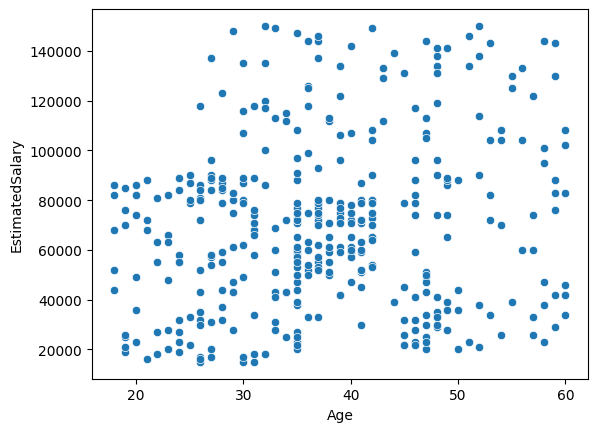

In [10]:
# import seaborn as sns

sns.scatterplot(x=inp['Age'], y=inp['EstimatedSalary'])

In [11]:
X=df[['Age','EstimatedSalary']]
y=df['Purchased']

In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)


In [13]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [15]:
model=Sequential()
model.add(Dense(128,activation='relu',input_dim=2))
model.add(Dense(1,activation='sigmoid'))

In [16]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['accuracy'])

In [20]:
history=model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=100)
#

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.4370 - loss: 1135.5126 - val_accuracy: 0.6000 - val_loss: 648.4924
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5971 - loss: 363.8353 - val_accuracy: 0.4000 - val_loss: 163.5987
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6009 - loss: 167.4002 - val_accuracy: 0.4000 - val_loss: 92.7236
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4784 - loss: 117.2894 - val_accuracy: 0.4000 - val_loss: 251.9501
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4686 - loss: 174.9424 - val_accuracy: 0.6000 - val_loss: 165.5736
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5154 - loss: 145.3031 - val_accuracy: 0.6000 - val_loss: 346.1573
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6231 - loss: 284.0516 - val_accuracy: 0.4000 - val_loss: 211.7832
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4645 - loss: 1

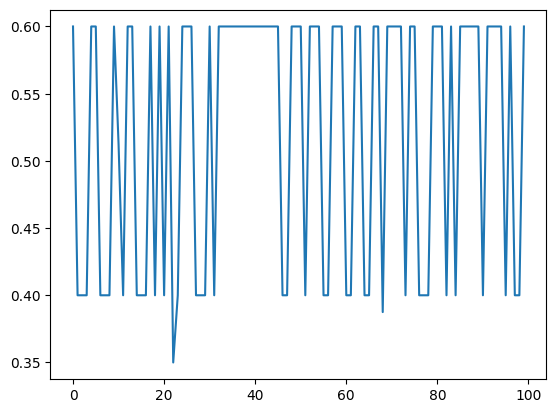

In [21]:
import matplotlib.pyplot as plt
plt.plot(history.history['val_accuracy'])


In [22]:
# now  normalize this and see the differnce
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train_scaled=sc.fit_transform(X_train)
X_test_scaled=sc.transform(X_test)


In [23]:
X_train_scaled
# -1 to 1 range as i have  standardized it

array([[ 0.88928823, -0.65924556],
       [-0.17254846,  0.87392651],
       [-1.04132394, -0.36440478],
       [ 0.98581884,  0.6085698 ],
       [-0.94479333,  0.57908572],
       [ 0.40663519,  0.01888824],
       [ 0.98581884,  2.11225779],
       [ 0.31010458, -0.30543662],
       [ 1.7580637 , -0.27595254],
       [-0.17254846,  2.20071003],
       [ 1.7580637 ,  1.0213469 ],
       [-1.33091576, -1.48479975],
       [ 2.04765553,  0.54960165],
       [ 1.27541066,  1.90586924],
       [-1.13785454,  0.31372902],
       [-0.36560968, -0.77718187],
       [-1.71703819,  0.49063349],
       [-0.5586709 , -1.51428383],
       [ 0.31010458, -0.71821372],
       [ 0.02051275, -0.57079333],
       [ 0.02051275,  0.04837232],
       [-0.07601785, -0.51182517],
       [-0.6552015 , -1.51428383],
       [ 0.02051275,  0.31372902],
       [ 0.31010458,  0.07785639],
       [-0.46214029, -1.13099081],
       [-0.75173211, -1.54376791],
       [-0.26907907, -0.65924556],
       [-1.13785454,

<Axes: >

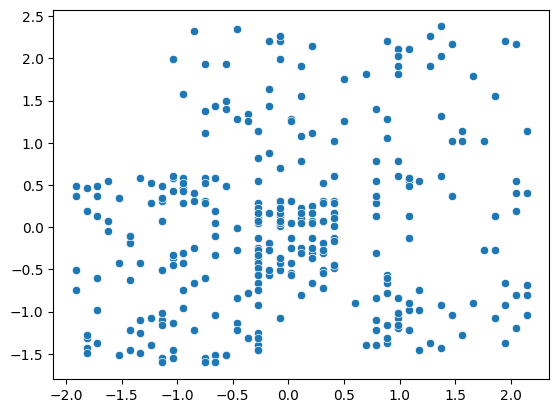

In [24]:
sns.scatterplot(x=X_train_scaled[:,0],y=X_train_scaled[:,1])


In [26]:
model=Sequential()
model.add(Dense(128,activation='relu',input_dim=2))
model.add(Dense(1,activation='sigmoid'))

In [28]:
model.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['accuracy'])
history=model.fit(X_train_scaled,y_train,validation_data=(X_test_scaled,y_test),epochs=100)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.4199 - loss: 0.7047 - val_accuracy: 0.8250 - val_loss: 0.6491
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8039 - loss: 0.6426 - val_accuracy: 0.8625 - val_loss: 0.5909
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8750 - loss: 0.5853 - val_accuracy: 0.8250 - val_loss: 0.5418
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8369 - loss: 0.5451 - val_accuracy: 0.8000 - val_loss: 0.5006
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.8458 - loss: 0.5064 - val_accuracy: 0.8000 - val_loss: 0.4655
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8584 - loss: 0.4696 - val_accuracy: 0.8250 - val_loss: 0.4344
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8686 - loss: 0.4330 - val_accuracy: 0.8125 - val_loss: 0.4090
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8519 - loss: 0.4105 - val_accuracy: 0.

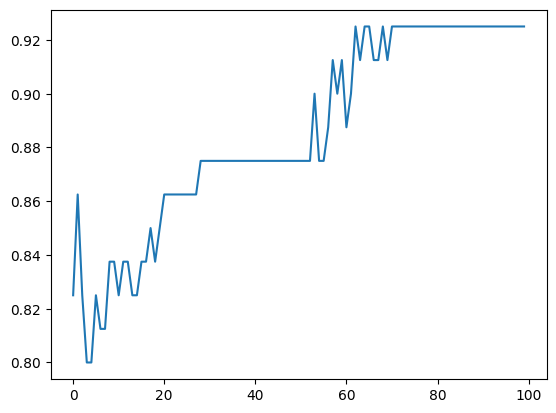

In [29]:
import matplotlib.pyplot as plt
plt.plot(history.history['val_accuracy'])